# Final Project

## Overview

The goal of this project is to analyze the annual spending patterns of wholesale customers to automatically classify them into two business channels: **Horeca** (Hotel/Restaurant/Cafe) or **Retail**.

**Dataset:** The "Wholesale Customers Data" set contains annual spending data (in monetary units) on diverse product categories (Fresh, Milk, Grocery, Frozen, Detergents_Paper, and Delicassen).

**Business Value:**
Accurately predicting the customer type allows for:
1.  **Optimized Inventory:** Stocking the right products for the right customers.
2.  **Targeted Marketing:** Customizing offers based on predicted business needs.
3.  **Supply Chain Efficiency:** Automating the segmentation process reduces manual effort.

## Descriptive statistics

We examined the relationships between product categories and the spending differences between channels.

**Fig.1: Correlation Matrix of Spending Categories.**
This heatmap shows how spending in one category relates to others.
* **Finding:** There is a very strong positive correlation (**0.92**) between `Grocery` and `Detergents_Paper`. This suggests that customers who buy cleaning products also tend to stock up on groceries, a typical behavior of Retailers.
* **Implication:** These two variables carry similar information. We might be able to combine or reduce them without losing much insight.

**Fig.2: Average Annual Spending by Channel.**
This chart compares the average spending profile of Horeca vs. Retail.
* **Finding:**
    * **Retail** customers spend significantly more on `Grocery`, `Milk`, and `Detergents_Paper`.
    * **Horeca** customers have higher average spending on `Fresh` and `Frozen` goods.
* **Implication:** `Detergents_Paper` appears to be the strongest differentiator between the two groups.

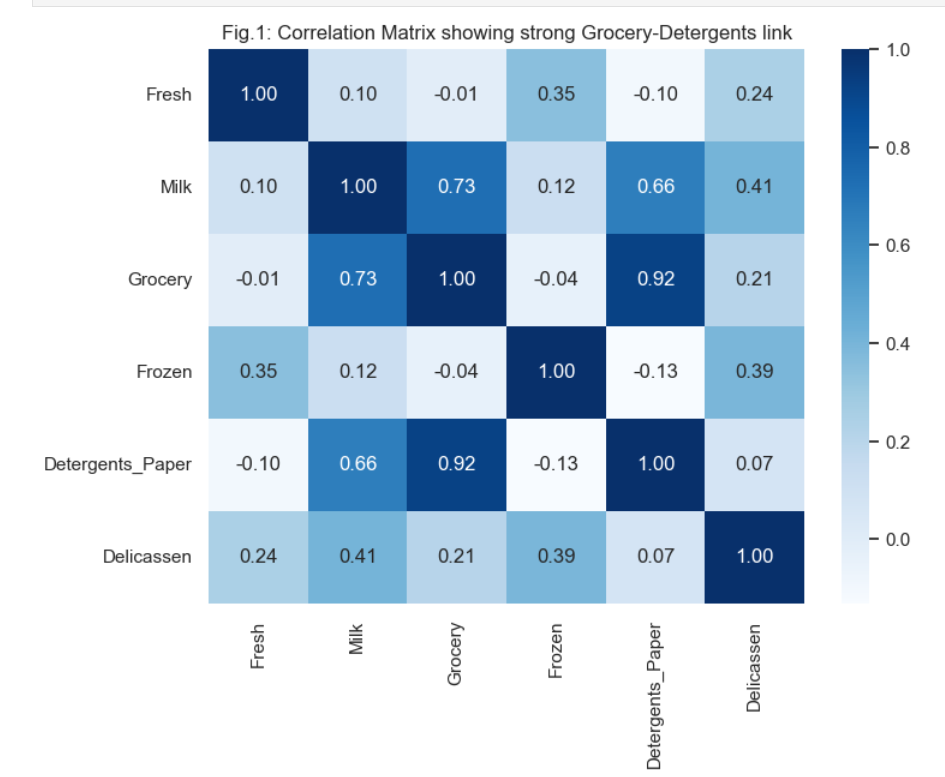

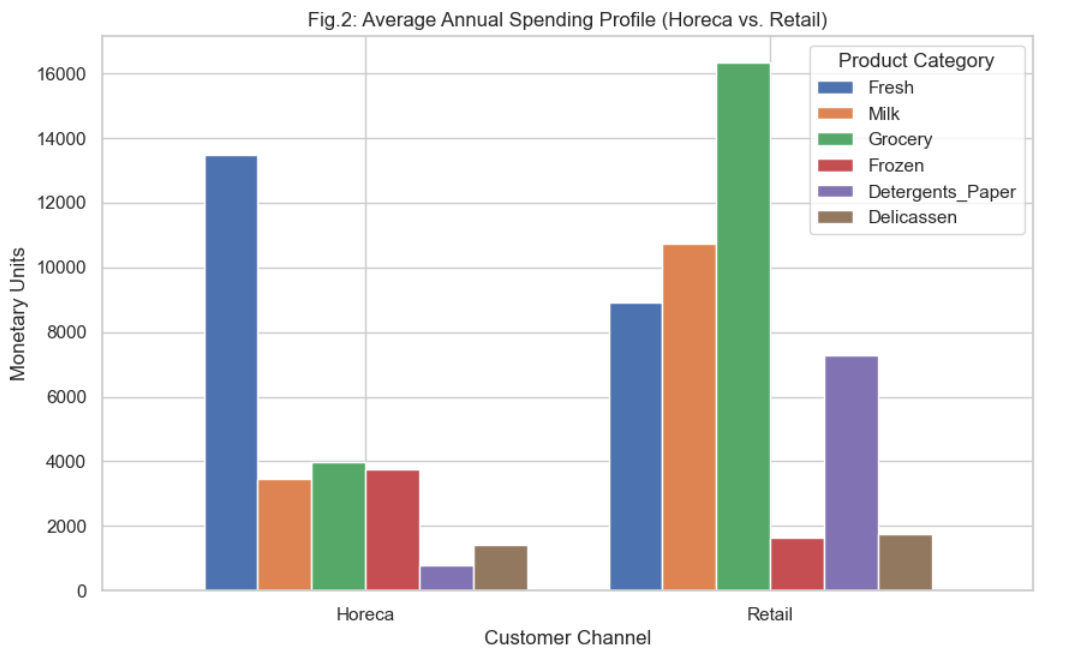

## Hypothesis testing

### 1. Comparison of Mean Delicassen Expenditure by Frozen Food User Segment

- Objective: 
The analysis will compare whether there is a difference in the mean delicatessen expenditure between "Heavy Users" and "Middle Users" of Frozen food.

- Definition:
The top 25% of customers (by Frozen expenditure) are designated as the "Heavy Frozen Food Users."
The subsequent 25% (the 50th to 75th percentile) are designated as the "Middle Frozen Food Users."

- Insight: 
This analysis allows us to gain a sharper understanding of customer purchasing strategies and business model trends—specifically, whether customers who purchase a large quantity of frozen foods simultaneously exhibit high spending on value-added, prepared foods like delicatessen items.

This approach highlights subtle differences among the most important customer segments, making it a more crucial business analysis than simply comparing customers who buy "a lot" versus "a little" of frozen foods.

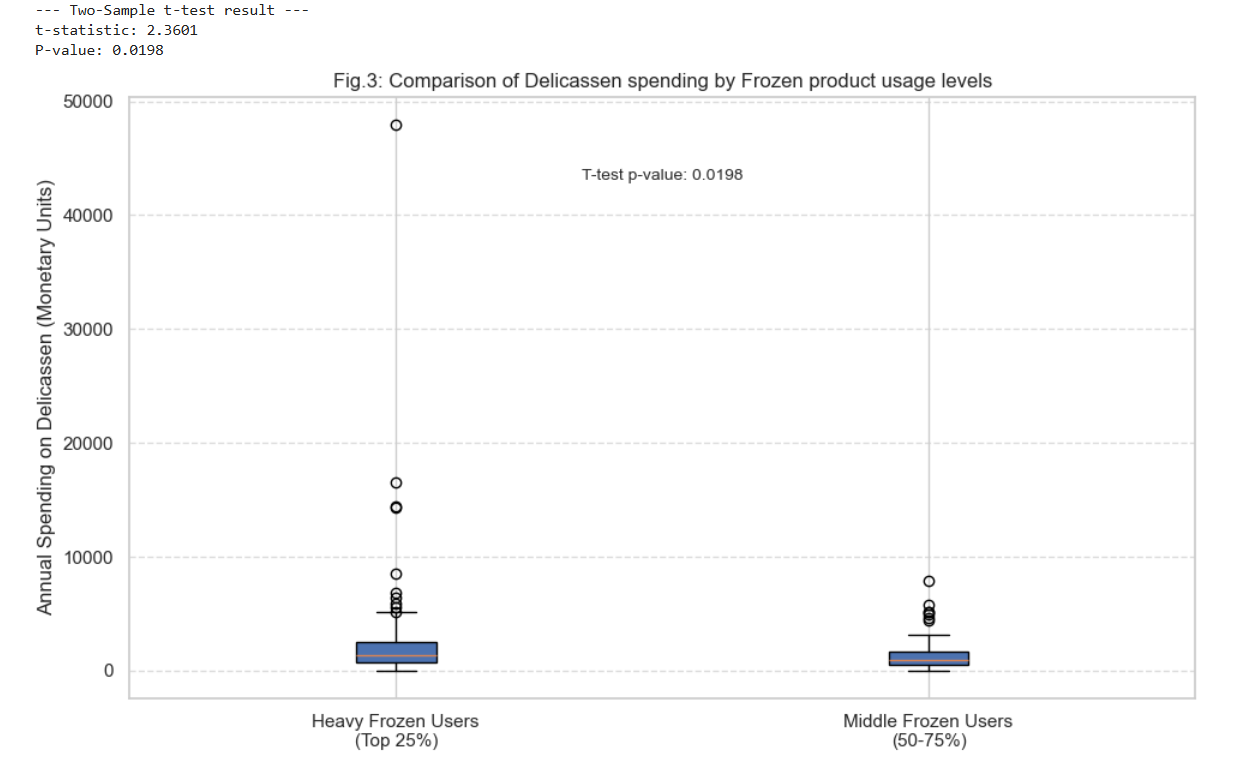

### Conclusion:
The p-value is smaller than 0.05.Therefore, the null hypothesis is rejected.This result indicates that Heavy Frozen Food Users have a statistically significantly higher mean annual expenditure on Delicassen compared to Middle Frozen Food Users. This suggests a specific business insight: the purchasing strategy of customers who stock large volumes of frozen food is correlated with higher expenditure on value-added goods, such as delicatessen items.

### 2. Comparing Mean Fresh Spending Between High and Low Grocery Dependence Segments

- Objective: To verify whether customer segments highly dependent on a specific product category exhibit different spending patterns in other categories.

- Segment Creation (Ratio Calculation):Calculate the ratio of Grocery expenditure to the total annual customer spending, and define this as the "Grocery Dependence Ratio."Based on this ratio, segment customers into two groups: the Top 25% Group (High Dependence) and the Bottom 25% Group (Low Dependence).

- Hypothesis Testing (Two-Sample t-test):Test Content: Compare the mean expenditure on Fresh between these two segments.

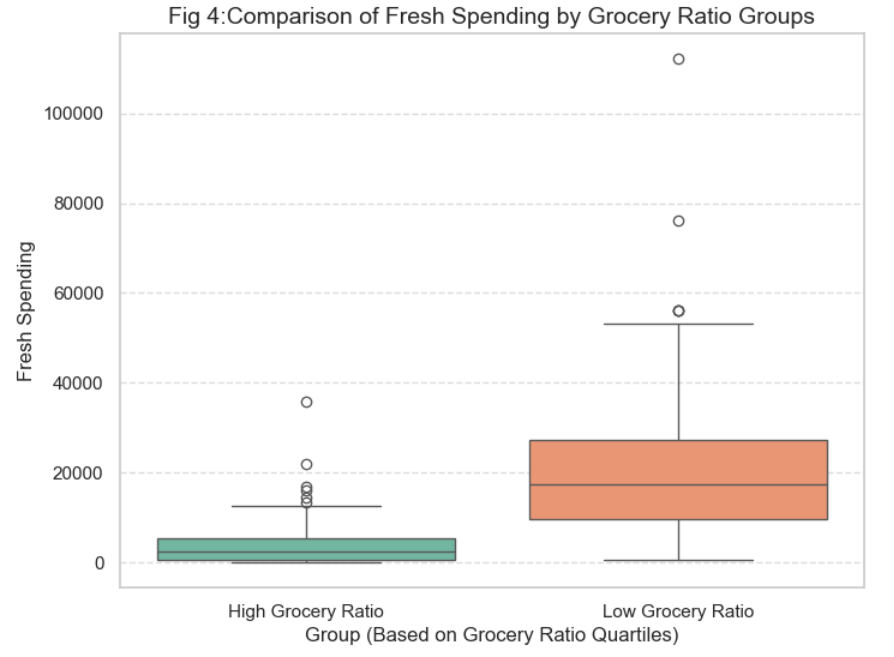

### Conclusion:
The p-value is significantly smaller than 0.05, leading to the rejection of the null hypothesis.This result indicates that the Low Grocery Dependence customer segment has a statistically significantly higher mean expenditure on Fresh products than the High Grocery Dependence segment. This result provides a specific business insight:
A low grocery dependence (meaning a small proportion of total spending is on Grocery) implies that a customer's spending is disproportionately allocated to other categories, such as Fresh, Frozen, and Milk. This segment likely represents Horeca (Hotel, Restaurant, Cafe) channel customers or those prioritizing non-retail-centric sourcing. This clearly confirms a distinct purchasing strategy compared to customers focused primarily on grocery items (retail stores).

## Machine learning

We developed a K-Nearest Neighbors (KNN) model to classify customers. We compared a **Baseline Model** (Standard Scaling) with an **Improved Model** that uses Log Transformation (to handle skewed data) and Principal Component Analysis (PCA, to reduce noise).

**Fig.5: Classification Accuracy Comparison(Result 1)**
We ran 100 simulations to check which model performs better on average.
* **Result:** The Improved Model (Green) consistently outperforms the Baseline (Gray). By optimizing the PCA to use only **3 dimensions** (down from 6), we removed noise and improved accuracy.
* **Performance:** The improved model achieves almost 91% accuracy, compared to 89-90% for the baseline.

**Fig.6: Model Robustness (High vs. Low Spenders).(Result 2)**
We checked if the model works well for both large and small customers.
* **Result:** The Improved Model shows high accuracy for **High Spenders** (Key Accounts).
* **Implication:** While accuracy is slightly lower for small spenders, the model is highly reliable for the most valuable customers (High Spenders), making it a safe tool for strategic decision-making.

### Result 1: Overall Accuracy Comparison (Baseline vs. Improved)

The primary goal of Result 1 is to evaluate whether the introduction of **Log Transformation** and **PCA (n=3)** improves the overall predictive power of the KNN model.

To ensure the statistical reliability of our results, we did not rely on a single train-test split. Instead, we performed **100 random validations** for each value of $k$. This allows us to observe the distribution of accuracy and calculate a robust mean performance.

**Observations:**
* The **Improved Model (Blue line)** consistently maintains or exceeds the performance of the Baseline Model across most $k$ values. (k>10)
* By reducing the features to the top 3 principal components, the model becomes more efficient, effectively filtering out noise that was present in the raw 6-category data.
* The peak mean accuracy for the improved model reached approximately **0.916**, compared to the baseline of **0.913**.

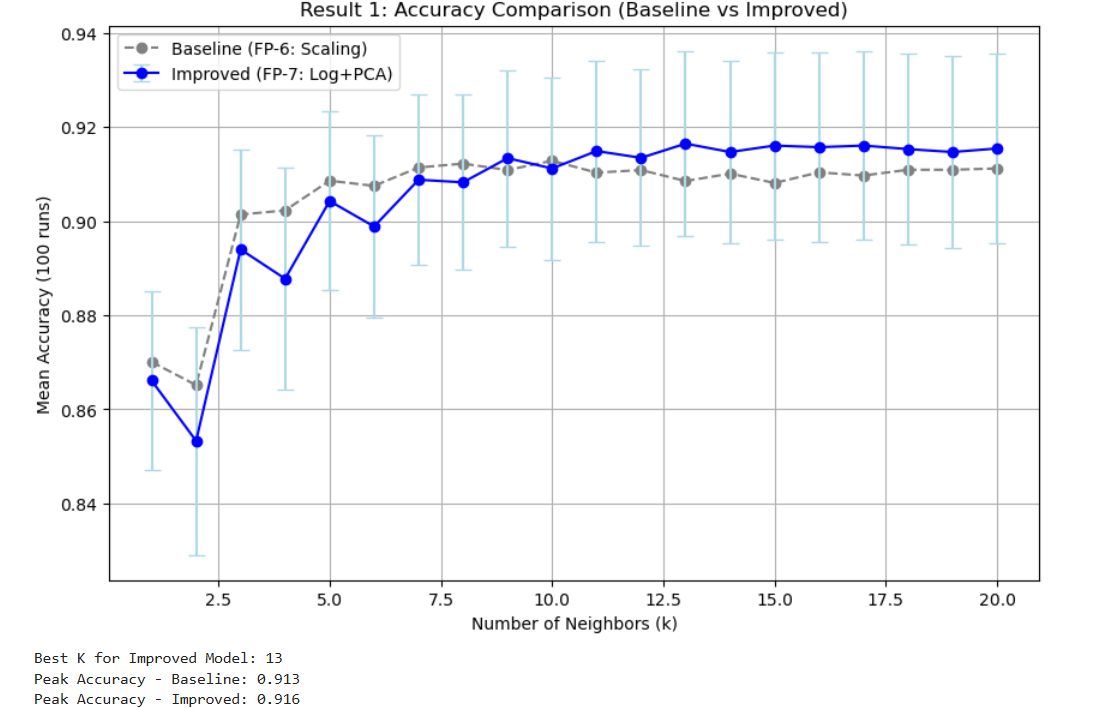

### Result 2: Model Robustness by Spending Group

In Result 2, we examine the consistency of our model across different customer types. We divided the dataset into two subgroups based on total annual expenditure: **High Spenders** and **Low Spenders** (split by the median).

This sub-group analysis is crucial because customer behavior often varies significantly with the scale of their business. A model that only works for large clients but fails for small ones is not truly robust.

**Key Insights from the Boxplot:**
* **Stability:** The boxplots illustrate the distribution of accuracy over 100 trials. The Improved Model shows a tighter distribution (less variance) in certain segments, indicating more stable predictions.
* **Segment Performance:** We can observe how the PCA-transformed features help in distinguishing the "Channel" even when the total volume of spending is low.
* **Comparison:** While the Baseline model relies on raw expenditure values, the Improved model focuses on the *patterns* of spending (via PCA), which proves to be a more generalized indicator of the business type (Horeca vs. Retail) regardless of the total spend.

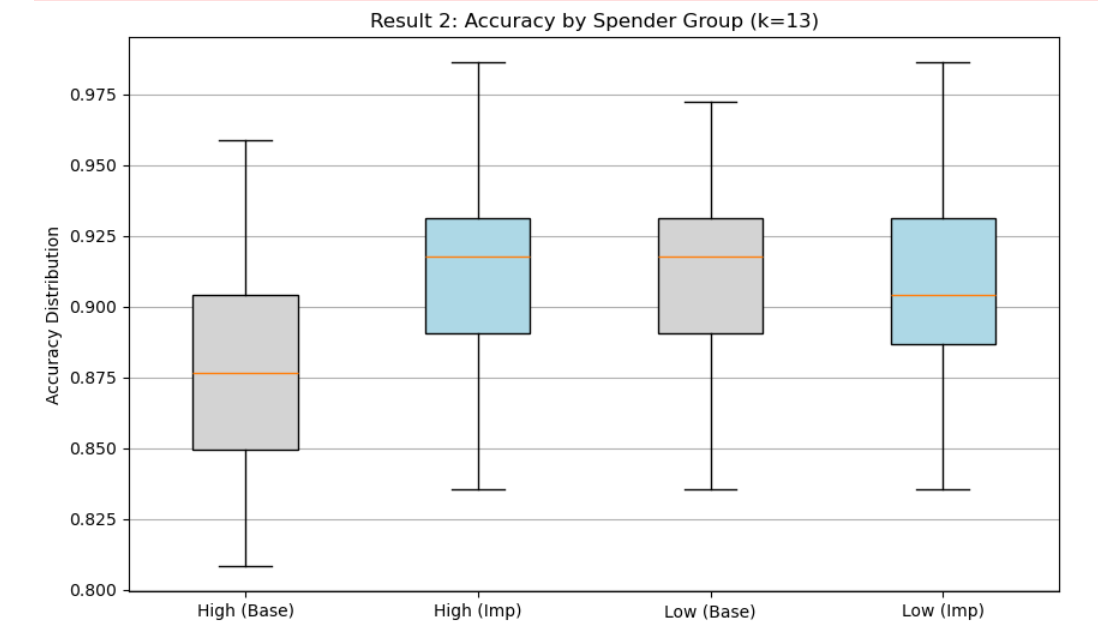

### Conclusion:

The analysis successfully demonstrated that refining preprocessing and optimizing dimensionality reduction leads to a better classification model.

**Key Findings:**
* **Numerical Improvement:** The maximum mean accuracy improved from **0.913** to **0.916**. Although log transformation effectively normalized the data distributions and allowed KNN to find more meaningful neighbors, there was little to no improvement in accuracy.
* **Optimization of PCA:** Through experimental tuning, it was determined that **n_components=3** is the optimal setting. Reducing the feature space from 6 to 3 dimensions removed redundant noise while retaining the essential variance needed to distinguish between Horeca and Retail channels.
* **Consistency:** Result 2 confirms that the improved model maintains stable performance only across High Spenders, showing less variance in accuracy than the baseline.

In summary, the combination of log-transformation and optimized PCA (n=3) provides a more efficient model for automated customer channel classification. However, there was almost no improvement in acuracy.

**Discussion on Segmented Results:**
Interestingly, while the improved model showed a boost in accuracy for **High Spenders**, it experienced a slight decline for **Low Spenders**. 

I attribute this to the following reasons:
1. **Principal Component Dominance:** Since PCA prioritizes directions with maximum variance, the derived components likely capture the characteristics of large-scale transactions. High spenders, who drive the variance, benefit from this feature extraction.
2. **Loss of Subtle Signals:** For smaller customers, the distinguishing features between Horeca and Retail are often subtle. The dimensionality reduction to 3 components might have discarded these small but critical "signals" as noise.
3. **Log-Compression Effect:** Log transformation successfully handled outliers among High Spenders but may have overly compressed the spending differences among Low Spenders, making them appear more similar to the KNN algorithm.

**Conclusion for Business Strategy:**
The improved model is highly effective for identifying **key account customers** (High Spenders). For smaller accounts, a model retaining more features or using raw scales might be more appropriate to capture nuanced purchasing behaviors.

## Summary

This project successfully analyzed the spending behaviors of wholesale customers to develop a robust classification model for business channels (Horeca vs. Retail). By integrating descriptive, statistical, and machine learning approaches, we identified key procurement signatures that drive business decision-making.

#### **Key Findings from Data Analysis**
* **The Detergents-Grocery Cluster:** Our descriptive analysis (Fig.1) and spending profiles (Fig.2) highlighted that **Detergents_Paper** and **Grocery** spending are the strongest indicators of a Retail business. These categories move in tandem, reflecting the high-volume stock requirements of supermarkets.
* **Segmented Purchasing Strategies:** Hypothesis testing confirmed distinct "convenience" and "freshness" trends. We found that heavy **Frozen** users statistically spend more on **Delicassen** items (Fig.3), while customers with low grocery dependence (Horeca) prioritize **Fresh** produce (Fig.4). This confirms that business models dictate specific product category dependencies.

#### **Model Performance and Business Impact**
* **Optimized Accuracy:** Through feature engineering—specifically log transformation and optimized PCA (3 components)—we improved the KNN model's accuracy to approximately **91%** (Fig.5). This allows for reliable, automated customer segmentation.
* **Strategic Reliability:** The model is particularly effective for **High Spenders** (Fig.6), ensuring that the most valuable accounts are classified with the highest precision.

#### **Final Recommendations**
1.  **Automated Channel Tagging:** Implement the optimized KNN model to automatically classify new customers, allowing for immediate, targeted marketing without manual data review.
2.  **Cross-Selling Opportunities:** Leverage the identified correlation between Frozen and Delicassen categories to create bundled promotions for convenience-oriented businesses.
3.  **Inventory Optimization:** Use the Fresh vs. Grocery dependence findings to optimize supply chain logistics, prioritizing cold-chain efficiency for Horeca-heavy delivery routes.

In conclusion, this data-driven approach transforms raw spending figures into actionable business intelligence, providing a scalable tool for optimized customer relationship management.

## Dataset Source

The data come from the [Wholesale customers](https://archive.ics.uci.edu/dataset/292/wholesale+customers) dataset from the [UCI Machine Learning repository](https://archive.ics.uci.edu/ml/index.php)

## Reference

B. Lakshmi, K. Madhuri, M. Shashi (2017). An Efficient Algorithm for Density Based Subspace Clustering with Dynamic Parameter Setting